[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation and Method Comparison

**Inputs.** The newest finished run of each method and seed under `outputs/optim/`, the baseline radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.

No GPU is needed and nothing is re-traced. Every table and figure is built by `src/evaluation/run.py`, the same code
`task evaluate` runs; this notebook only presents them.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.evaluation.run import evaluate
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/04_evaluation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/04_evaluation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

Build every table and figure once. Run directories that did not finish writing are skipped with a `WARNING` line.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)

WARNING skipping outputs\optim\random\2026-09-16_08-25-34: No outputs\optim\random\2026-09-16_08-25-34\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\random\2026-09-16_14-49-31: No outputs\optim\random\2026-09-16_14-49-31\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\random\2026-09-17_03-21-43: No outputs\optim\random\2026-09-17_03-21-43\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\rule\2026-09-16_08-34-27: No outputs\optim\rule\2026-09-16_08-34-27\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\rule\2026-09-16_15-01-07: No outputs\optim\rule\2026-09-16_15-01-07\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_08-36-09: No outputs\optim\turbo\2026-09-16_08-36-09\evaluation.parquet. The run did not finish writing.
WARNING skipping outputs\optim\turbo\2026-09-16_14-32-24: No outputs\optim\turbo

## 1. Evaluation Objective

This notebook compares search methods for **multi-band antenna tilt coordination**: one absolute tilt per cell-band
pair, chosen to

* reduce coverage holes,
* reduce co-band coverage overlap and the number of overlapping neighbours,
* reduce weak coverage,
* serve more UEs within the cells' PRB capacity,

at a reasonable number of expensive ray-tracing evaluations. The KPIs are reported side by side and weighed equally;
none is ranked above another. The single number a search maximises is the objective $J$ of
`docs/adr/0006-radio-load-cvar-objective.md`, which is reported beside the KPIs, not in place of them.

## 2. Methods Under Evaluation

| Method | Key | Type | Description |
|---|---|---|---|
| Current configuration | `incumbent` | Reference | The committed tilts, evaluation 0 of every run |
| Random search | `random` | Baseline | Scrambled Sobol samples over the tilt box; its first `n_init` points are TuRBO's initial design (`configs/optim/method/random.yaml`) |
| Rule-based sweep | `rule` | Baseline | Operator heuristic: one shared tilt per band, coordinate descent over a grid of values (`configs/optim/method/rule.yaml`) |
| TuRBO | `turbo` | Proposed | TuRBO-1 trust-region Bayesian optimisation on $J$ (`configs/optim/method/turbo.yaml`, ADR 0003/0006) |

Random search and TuRBO share seed and evaluation budget, so they differ only in where they look. The rule-based
sweep is not budget-matched. There is no separate plain-random arm apart from Sobol, and the Multi-Agent
Reinforcement Learning arm is not implemented.

## 3. Experimental Setup

### 3.1 Tilt search space

For each cell-band pair $(i,b)$ the decision variable is the absolute tilt $\theta_{i,b}$, continuous within its bounds:

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

No tilt step and no maximum change from the current tilt $\theta^{(0)}$ are imposed; how far antennas moved is
reported in Section 13, not constrained.

### 3.2 Network, search space and budget

UE counts are over every UE. A search scores candidates on the MDT subset; the published winners are re-scored on
every UE (`src/evaluation/__init__.py`).

In [4]:
display(results["experiment_setup"])

,Parameter,Setting
0,Scenario,scn_7d938e15f9ac4618
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Decision variables (cell-band tilts),36
4,Evaluation area [m],6200 x 6520
5,Grid resolution [m],20
6,Grid tiles,101060
7,UE reports,10066
8,Measurement intervals,672
9,Tilt bounds [°],0 to 15


## 4. Evaluation KPIs

Notation: $R_{i,b}(g)$ is the RSRP of cell $i$ on band $b$ at tile $g \in G$, and $R_s(g) = \max_{(i,b)} R_{i,b}(g)$ the
strongest layer. The thresholds $T_{\text{hole}}$, $T_{\text{weak}}$ and $\Delta_{\text{overlap}}$ are
`kpi.hole_dbm`, `kpi.weak_dbm` and `kpi.overlap_margin_db` in `configs/kpi.yaml`; their values are in the setup table
above. The implementations are in `src/kpi/`.

### 4.1 Coverage hole rate (minimise)

$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[R_s(g)\le T_{\text{hole}}\right]
$$

A tile with no ray-traced path counts as a hole.

### 4.2 Co-band overlap rate (minimise)

Overlap is **co-band**: within band $b$, the strongest transmitter serves, and each other transmitter $j$ on that band
is an overlapping neighbour when

$$
R_{j,b}(g) > T_{\text{hole}} \quad\text{and}\quad R_{j,b}(g) \ge \max_i R_{i,b}(g) - \Delta_{\text{overlap}}.
$$

$N_{\text{ov}}(g)$ is that count summed over bands, and $\mathrm{OverlapRate} = |\{g : N_{\text{ov}}(g) > 0\}| / |G|$.

### 4.3 Mean overlap neighbours (minimise, diagnostic)

$$
\mathrm{MeanOverlapNeighbours} = \frac{1}{|G_{\text{covered}}|}\sum_{g\in G_{\text{covered}}} N_{\text{ov}}(g),
\qquad G_{\text{covered}} = \{g : R_s(g) > T_{\text{hole}}\}.
$$

This separates one competing neighbour from pile-ups of many. It is computed from archived radio maps, so it exists
only for the current configuration and each method's winner.

### 4.4 Weak coverage rate (minimise)

$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[T_{\text{hole}} < R_s(g) \le T_{\text{weak}}\right]
$$

### 4.5 Served UE ratio (maximise)

The share of UE reports admitted to a cell-band above $T_{\text{hole}}$ under the serving rule and the PRB limits of
`src/kpi/capacity.py`. The capacity settings are placeholders, so read its direction rather than its level.

### 4.6 Cell-edge RSRP (maximise)

The `kpi.quality.edge_percentile` percentile of serving RSRP over covered tiles, read beside the hole rate.

### 4.7 Objective $J$ (maximise)

$$
J = J_{\text{radio}}^{\gamma}\, J_{\text{load}}^{1-\gamma}
$$

$J_{\text{radio}}$ is a coverage sigmoid discounted per overlapping neighbour; $J_{\text{load}}$ penalises the CVaR of PRB
utilisation above $\rho_0$. Parameters are in `kpi.objective` (ADR 0006).

## 5. Result Loading and Validation

`evaluate` loaded the newest finished run of each method and seed; unfinished run directories were skipped above. Runs are compared only if they share the scenario, grid,
solver settings, bands and KPI definition; otherwise `evaluate` raises. The recorded KPIs are then recomputed from
each archived radio map: any visible gap means the archived map is not the map that was scored.

In [5]:
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")
display(checks)
reproducibility = results["kpi_reproducibility"]
print(f"Largest recorded-vs-recomputed gap: {reproducibility['Absolute gap'].max():.2e}")

21 of 21 comparability checks hold


,Check,Holds,Offending runs
0,every run optimized the baseline's scenario,True,
1,grid n_rows matches the baseline,True,
2,grid n_cols matches the baseline,True,
3,grid tile_size_m matches the baseline,True,
4,grid origin_x matches the baseline,True,
5,grid origin_y matches the baseline,True,
6,grid ue_height_m matches the baseline,True,
7,solver samples_per_tx matches the baseline,True,
8,solver max_depth matches the baseline,True,
9,solver los matches the baseline,True,


Largest recorded-vs-recomputed gap: 2.56e-06


**Observations.** All comparability checks hold, and the KPIs recomputed from each archived radio map match the recorded ones to float round-off. The three runs measure the same thing, so their differences come from tilt alone. One search seed (42) per method was found; every older run directory lacks `evaluation.parquet` and was skipped.

## 6. Final KPI Comparison

### 6.1 Best configuration per method

Each method's winner, re-scored on every UE and averaged over seeds, against the current configuration. With one seed
per method the spread and interval columns are empty.

In [6]:
display(results["kpi_scoreboard"])
display(results["method_cost"])

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1840,0.1680,NaN,NaN,NaN,-0.0160,better
1,Random search,Co-band overlap rate,minimise,1,0.2689,0.2810,NaN,NaN,NaN,0.0121,worse
2,Random search,Served UE ratio,maximise,1,0.4121,0.5069,NaN,NaN,NaN,0.0948,better
3,Random search,Weak coverage rate,minimise,1,0.4063,0.2847,NaN,NaN,NaN,-0.1216,better
4,Random search,Cell-edge RSRP,maximise,1,-112.2728,-109.9979,NaN,NaN,NaN,2.2749,better
5,Random search,Radio utility J_radio,maximise,1,0.5568,0.5777,NaN,NaN,NaN,0.0209,better
6,Random search,Load utility J_load,maximise,1,0.8349,0.8616,NaN,NaN,NaN,0.0267,better
7,Random search,Objective J,maximise,1,0.6818,0.7055,NaN,NaN,NaN,0.0237,better
8,Rule-based sweep,Coverage hole rate,minimise,1,0.1840,0.1639,NaN,NaN,NaN,-0.0201,better
9,Rule-based sweep,Co-band overlap rate,minimise,1,0.2689,0.2744,NaN,NaN,NaN,0.0055,worse


,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Radio utility J_radio,Load utility J_load,Objective J,KPIs improved,KPIs worsened
0,Random search,42,2026-09-17_07-25-42,145,7,12.1439,15.3656,0.1680,0.2810,0.5069,0.2847,-109.9979,0.5777,0.8616,0.7055,6,1
1,Rule-based sweep,42,2026-09-17_07-41-04,28,20,1.1977,2.2115,0.1639,0.2744,0.5163,0.2594,-109.3382,0.5843,0.8681,0.7122,6,1
2,TuRBO,42,2026-09-17_07-57-05,145,144,9.8646,19.4349,0.1659,0.2730,0.5133,0.2632,-109.3873,0.5864,0.8656,0.7124,6,1


### 6.2 Improvement over the current configuration

$$
\Delta K = \pm\,\frac{K_{\text{optimised}} - K_{\text{initial}}}{|K_{\text{initial}}|}\times 100\,\%,
$$

signed so that a positive value is an improvement whichever direction the KPI runs.

,Method,Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Radio utility J_radio,Load utility J_load,Objective J
0,Random search,8.7052,-4.5045,22.9990,29.9335,2.0263,3.7530,3.1930,3.4726
1,Rule-based sweep,10.9205,-2.0572,25.2893,36.1535,2.6138,4.9359,3.9714,4.4525
2,TuRBO,9.8344,-1.5420,24.5661,35.2329,2.5701,5.3153,3.6734,4.4911


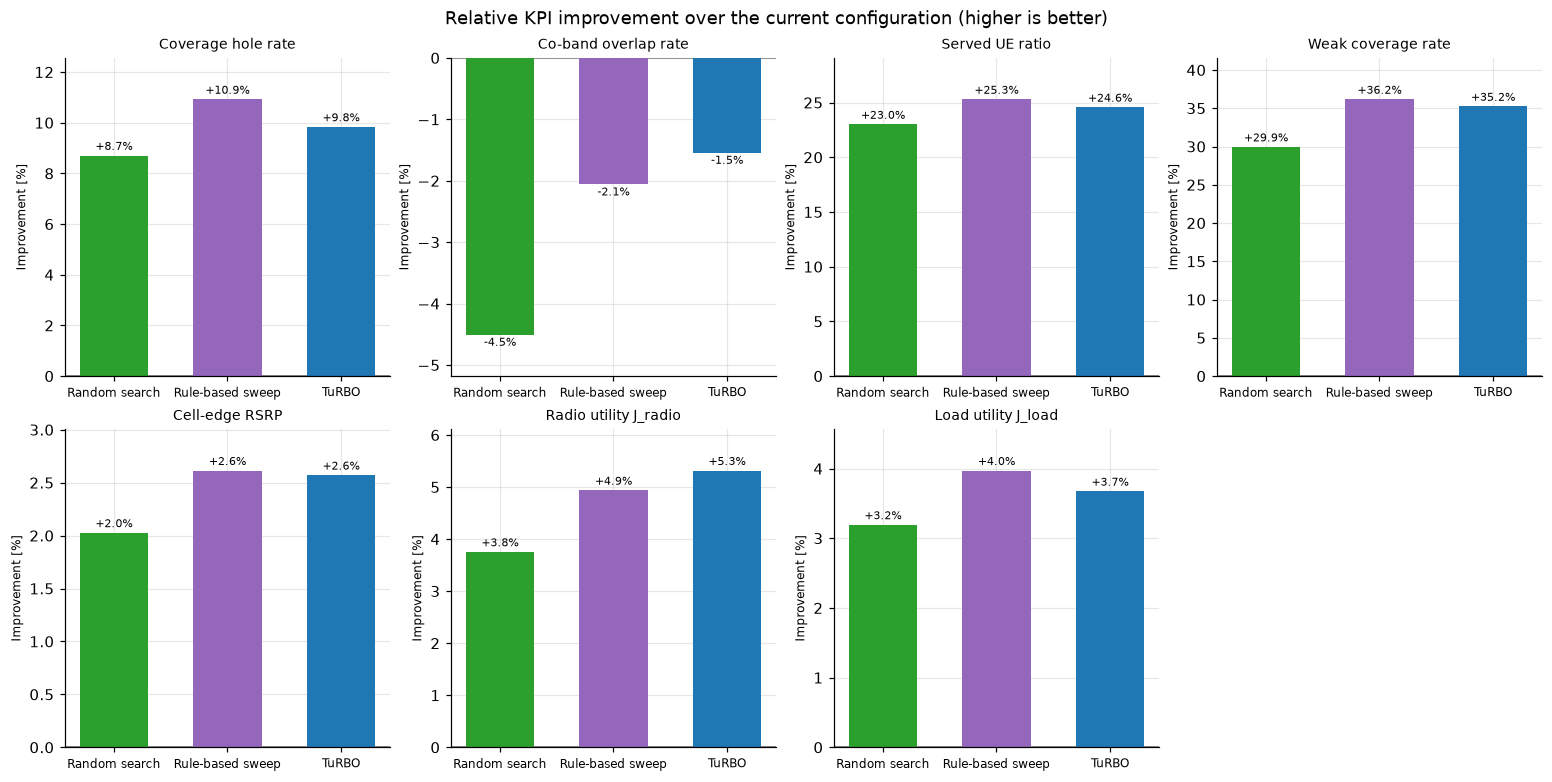

In [7]:
display(results["kpi_relative_improvement"])
display(results["kpi_improvement"])

**Observations.** All three methods improve six of the seven measures and worsen one, the co-band overlap rate, by between 1.5 % (TuRBO) and 4.5 % (random search) relative. The largest gains are in weak coverage (about 30–36 % fewer weak tiles) and served UE ratio (about 23–25 %), with a 9–11 % cut in hole rate and a 2–3 dB higher cell-edge RSRP. TuRBO and the rule-based sweep are practically tied on the objective (0.7124 against 0.7122). The sweep is slightly better on holes, weak coverage and served ratio; TuRBO is slightly better on overlap and J_radio. Random search trails both on every measure.

## 7. Optimization Convergence

Best objective score found so far against the number of evaluations, the current configuration being evaluation 1.
The band is the min–max over seeds and collapses to the line with one seed. This is a search trace, so it is scored on
the MDT.

The second table asks whether the search mattered: each winner against the typical candidate its own search evaluated.

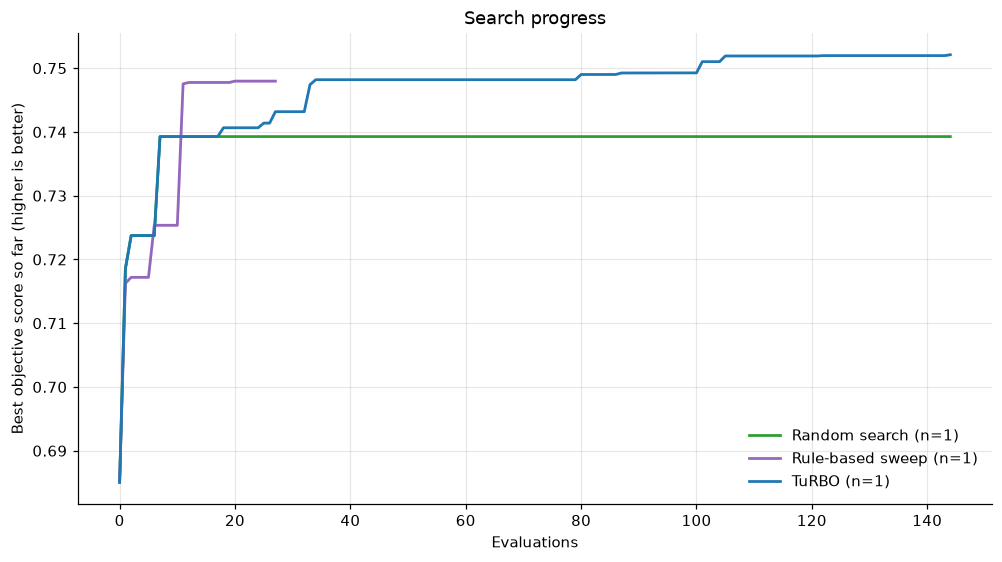

,Method,Seed,Current configuration,"Initial design, median score","All candidates, median score","All candidates, 90th percentile score",Best score found
0,Random search,42,0.6851,0.7192,0.7198,0.7275,0.7393
1,Rule-based sweep,42,0.6851,NaN,0.7254,0.7476,0.7480
2,TuRBO,42,0.6851,0.7192,0.7454,0.7504,0.7521


In [8]:
display(results["search_progress"])
display(results["winner_vs_candidates"])

**Observations.** On the MDT, the median candidate of TuRBO's search (0.745) already scores above random search's best (0.739). The trust region spends its budget near good configurations, while random search's candidates stay close to its Sobol design median. Random search found its best at evaluation index 7 and never improved after that. The rule-based sweep's median candidate is also high because it moves every cell of a band together.

## 8. Sample Efficiency

Best value reached after a fixed number of evaluations, averaged over seeds (MDT-scored). Each KPI is its own running
best, so the rows of one budget need not come from one configuration. The last budget is the longest run; a budget past
a run's length is empty.

In [9]:
display(results["sample_efficiency"])

,KPI,Evaluations,Random search,Rule-based sweep,TuRBO
0,Objective J,10,0.7393,0.7254,0.7393
1,Objective J,25,0.7393,0.7480,0.7407
2,Objective J,50,0.7393,NaN,0.7482
3,Objective J,100,0.7393,NaN,0.7493
4,Objective J,145,0.7393,NaN,0.7521
5,Coverage hole rate,10,0.1680,0.1739,0.1680
6,Coverage hole rate,25,0.1680,0.1623,0.1680
7,Coverage hole rate,50,0.1680,NaN,0.1661
8,Coverage hole rate,100,0.1680,NaN,0.1651
9,Coverage hole rate,145,0.1680,NaN,0.1651


**Observations.** The rule-based sweep reaches J = 0.748 in 25 evaluations. TuRBO needs about 50 evaluations to match that and ends at 0.752 after 145. Random search stays at the value it reached within its first 10 evaluations. The running-best overlap rate barely moves: only the rule sweep finds a candidate with slightly less overlap than the current configuration, and that candidate scores poorly.

## 9. Stability and Statistical Comparison

TuRBO against random search, paired by seed because both share each seed's Sobol design: mean gain in objective score,
its 95 % t-interval and a Wilcoxon signed-rank test.

**Only one seed per method exists**, so no interval, spread or test can be computed. The rows below are the single
paired difference, not evidence of a consistent advantage. Repeating `task optim` over more seeds (e.g.
`task sweep -- seed=1,2,3`) would fill them.

In [10]:
display(results["paired_gain_turbo_vs_random"])

,Method,Reference,Seed pairs,Mean score gain,95% CI lower,95% CI upper,Seeds won,Wilcoxon p-value
0,TuRBO,Random search,1,0.0069,NaN,NaN,1,NaN


## 10. Multi-Objective Trade-Offs and Pareto Fronts

Each point is one evaluated configuration (MDT-scored). The stars mark each method's highest-$J$ configuration, the
cross marks the current configuration, and the dashed line joins the Pareto-efficient configurations over all methods:
those that no other configuration beats on both axes at once.

The served UE ratio takes the place of the template's band-priority axis, which is not used in this project.

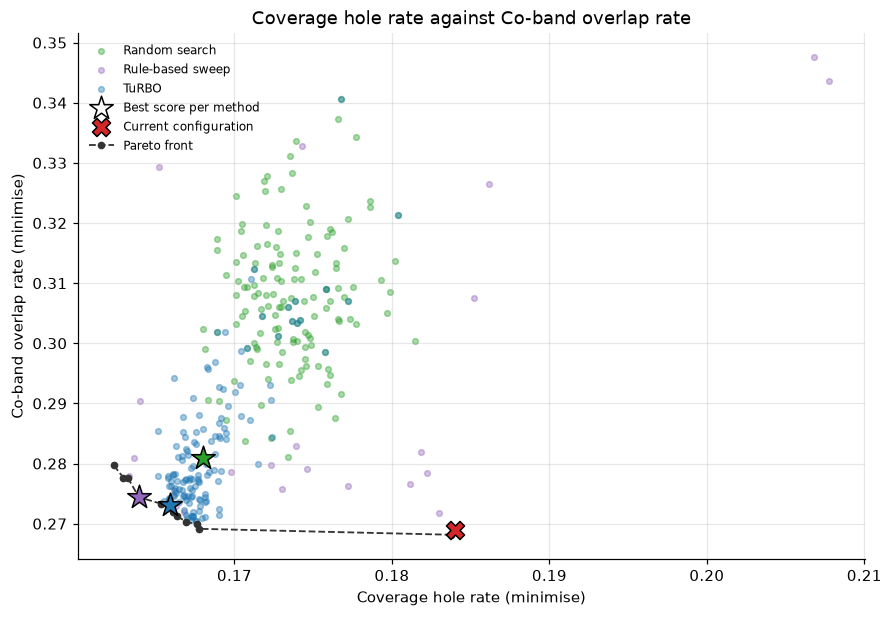

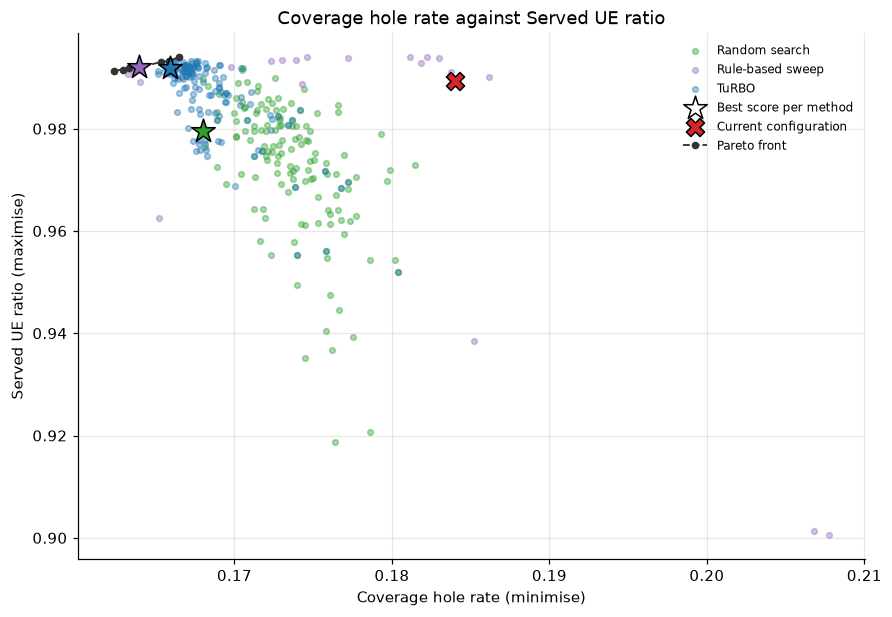

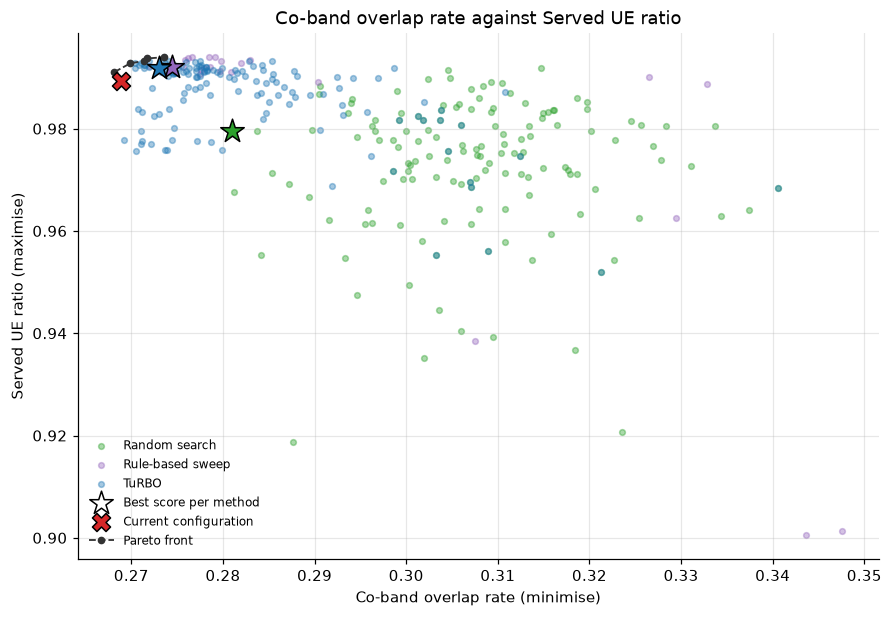

In [11]:
display(results["tradeoff_hole_rate_vs_overlap_rate"])
display(results["tradeoff_hole_rate_vs_served_ratio"])
display(results["tradeoff_overlap_rate_vs_served_ratio"])

**Observations.** Hole rate and overlap rate conflict: along the Pareto front, every step towards fewer holes costs overlap. The low-overlap end of the front is a rule-sweep candidate that barely changes the current configuration's holes. The low-hole end is made up of other rule-sweep candidates, and TuRBO's final candidates fill the middle. TuRBO's and the sweep's picks both lie on the front; random search's pick is dominated. Random search's candidates spread towards high overlap.

## 11. Spatial Coverage Analysis

### 11.1 Change in best-server RSRP per method

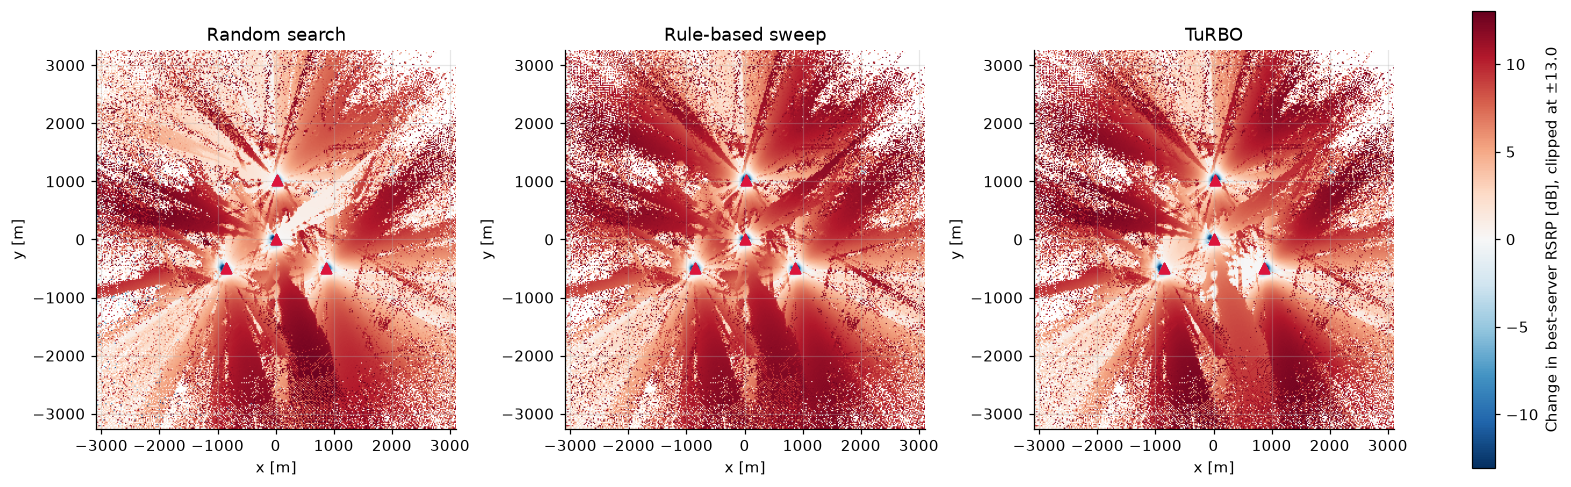

In [12]:
display(results["rsrp_change_maps"])

### 11.2 Before and after: the recommended configuration

The recommended configuration is the run with the highest objective score over all methods. Both panels use the same
scale and the same coverage classes.

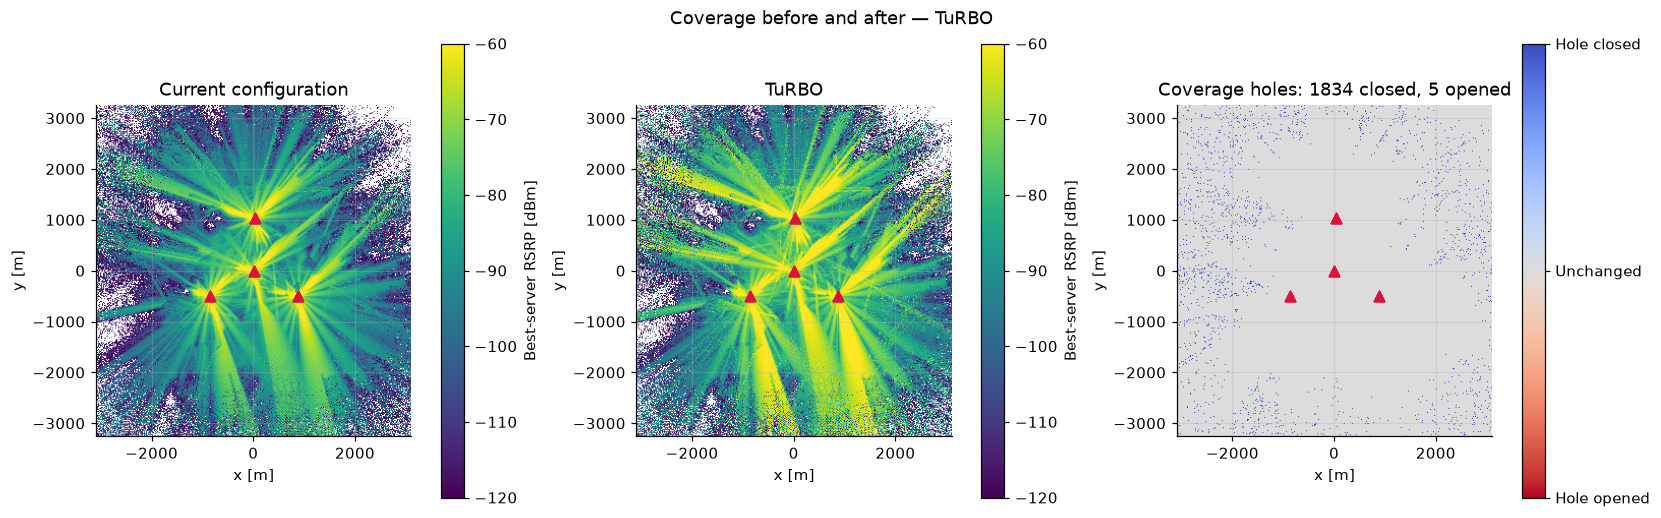

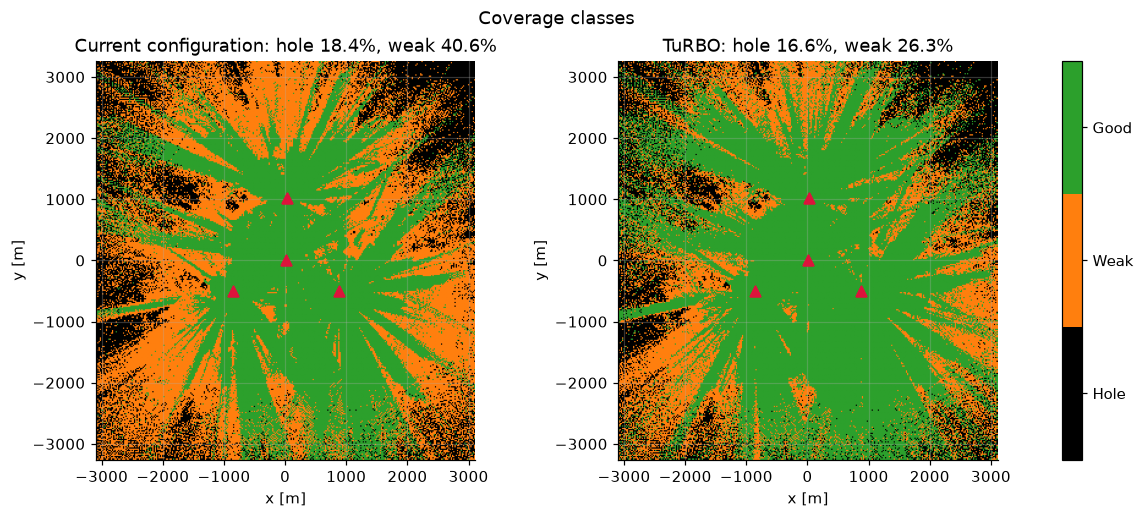

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1840,0.0000,0.1680,0.0033,0.1639,0.0000,0.1659,0.0000
1,weak,0.4063,0.9208,0.2847,0.8065,0.2594,0.7731,0.2632,0.7781
2,good,0.4097,0.0792,0.5473,0.1901,0.5767,0.2269,0.5709,0.2219


In [13]:
display(results["coverage_before_after"])
display(results["coverage_class_maps"])
display(results["coverage_by_area_and_demand"])

### 11.3 Overlap neighbours

,Configuration,"Mean overlap neighbours, covered tiles","Mean overlap neighbours, all tiles",Share with 0 neighbours,Share with 1 neighbour,Share with 2 neighbours,Share with 3+ neighbours
0,Current configuration,0.8818,0.7196,0.6705,0.1030,0.0632,0.1633
1,Random search,0.9013,0.7498,0.6623,0.1199,0.0730,0.1448
2,Rule-based sweep,1.0179,0.8510,0.6718,0.0969,0.0763,0.1550
3,TuRBO,0.9371,0.7816,0.6727,0.1080,0.0742,0.1451


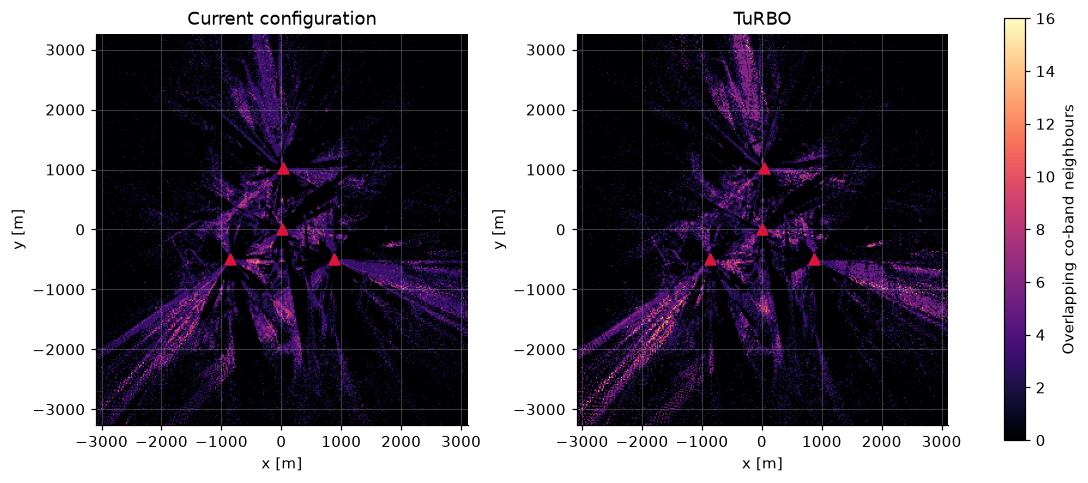

In [14]:
display(results["overlap_neighbour_summary"])
display(results["overlap_neighbour_maps"])

**Observations.** The recommended TuRBO configuration turns much weak area into good coverage. Weighted by demand, holes are already near zero before optimisation, so the holes it closes carry almost no users; the demand on weak tiles falls from about 92 % to 78 %. Mean overlap neighbours over covered tiles rise under every method (0.88 currently, 0.94 TuRBO, 1.02 rule), and the share of tiles with three or more overlapping neighbours falls from 16.3 % to 14.5 % for TuRBO.

## 12. Frequency-Layer Analysis

Per band: the area the band covers above the hole threshold and its mean RSRP there, the area the serving rule assigns
to it, and the share of UE reports actually admitted on it after PRB limits, with their median SINR. The band preference
of the serving rule is `kpi.capacity.band_preference`.

,Configuration,Band,Share of area covered by the band,Mean band RSRP where covered [dBm],Share of area served on the band,Share of UE reports served on the band,"Served SINR on the band, median [dB]"
0,Current configuration,2600 MHz,0.6302,-97.6115,0.6358,0.2833,2.7638
1,Current configuration,1800 MHz,0.6798,-94.8018,0.0895,0.0533,2.5072
2,Current configuration,700 MHz,0.7808,-89.6130,0.1776,0.0754,8.9900
3,Random search,2600 MHz,0.6623,-92.3108,0.6683,0.3701,4.7931
4,Random search,1800 MHz,0.7000,-89.1957,0.0734,0.0566,3.2060
5,Random search,700 MHz,0.7952,-84.0195,0.1612,0.0802,11.6931
6,Rule-based sweep,2600 MHz,0.6695,-91.3498,0.6743,0.3864,5.1557
7,Rule-based sweep,1800 MHz,0.7085,-88.0966,0.0733,0.0499,2.8783
8,Rule-based sweep,700 MHz,0.7978,-82.6991,0.1554,0.0801,12.6024
9,TuRBO,2600 MHz,0.6644,-92.2012,0.6692,0.3780,4.8990


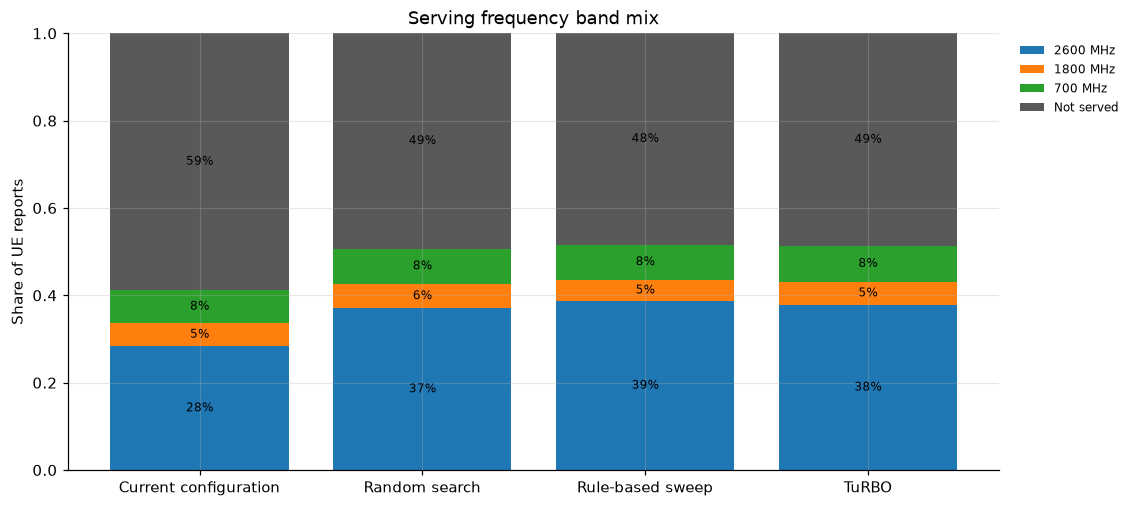

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10066.0,0.5879,-1.5773,4.0259,61.1037,0.2833,0.0533,0.0754
1,Random search,10066.0,0.4931,-0.9727,6.0582,47.6475,0.3701,0.0566,0.0802
2,Rule-based sweep,10066.0,0.4837,-0.8595,6.2215,46.7724,0.3864,0.0499,0.0801
3,TuRBO,10066.0,0.4867,-0.6874,5.9724,48.1178,0.3780,0.0533,0.0820


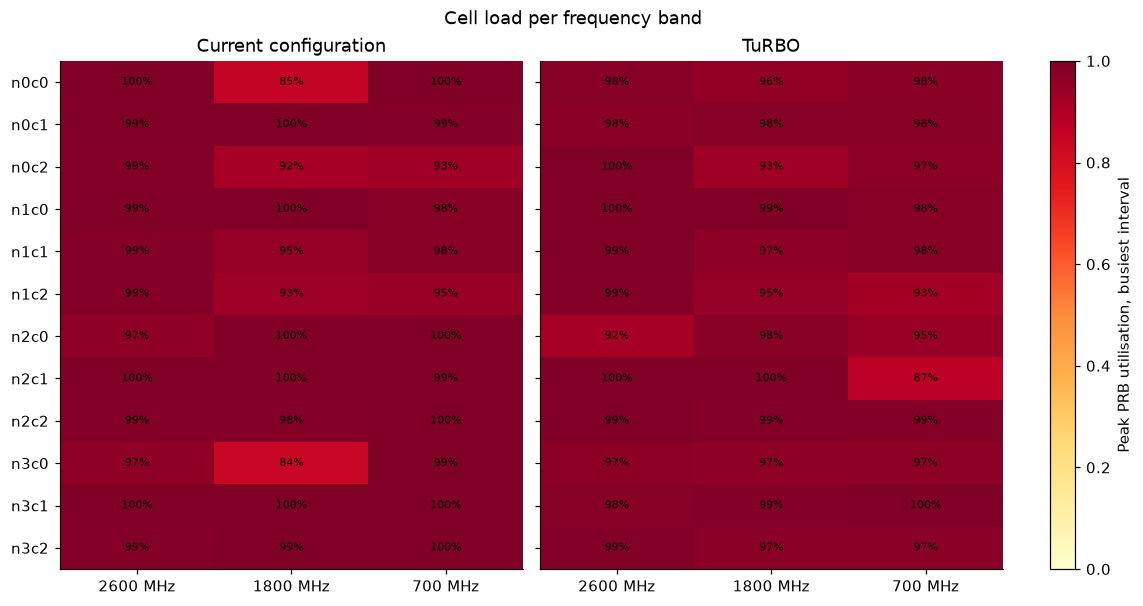

In [15]:
display(results["band_layer_summary"])
display(results["serving_band_mix"])
display(results["ue_service_summary"])
display(results["cell_band_utilisation"])

**Observations.** Every band covers more area after optimisation, and its mean RSRP where covered rises by about 5–7 dB. The share of UE reports served on 2600 MHz grows from 28 % to 38 % under TuRBO, while 1800 MHz and 700 MHz stay nearly flat, so the extra served UEs come mainly from the preferred high band. They are not shifted off the lower layers. The median served SINR rises on every band, most on 700 MHz (9.0 to 12.4 dB). Half of the UE reports are still not served, which is the placeholder capacity model at work, not coverage; most cell-bands already run close to full PRB utilisation in the current configuration.

## 13. Tilt Configuration Analysis

$$
\Delta\theta_{i,b} = \theta^{*}_{i,b} - \theta^{(0)}_{i,b}
$$

for the recommended configuration. Negative is uptilt. The cell impact table is sorted by how much traffic each
cell-band gained or lost, so the cells to watch after rollout come first.

,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,8.6506,-3.3494,0.0,15.0
1,n0c0,1800 MHz,12.0,1.3738,-10.6262,0.0,15.0
2,n0c0,700 MHz,12.0,2.6758,-9.3242,0.0,15.0
3,n0c1,2600 MHz,12.0,2.3407,-9.6593,0.0,15.0
4,n0c1,1800 MHz,12.0,4.7417,-7.2583,0.0,15.0
5,n0c1,700 MHz,12.0,3.6049,-8.3951,0.0,15.0
6,n0c2,2600 MHz,12.0,3.3161,-8.6839,0.0,15.0
7,n0c2,1800 MHz,12.0,2.1226,-9.8774,0.0,15.0
8,n0c2,700 MHz,12.0,5.1526,-6.8474,0.0,15.0
9,n1c0,2600 MHz,12.0,4.2175,-7.7825,0.0,15.0


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,7.7810,10.6262,-7.7810
1,2600 MHz,12,12,7.0297,10.6104,-7.0297
2,700 MHz,12,12,7.4800,11.9352,-7.4703


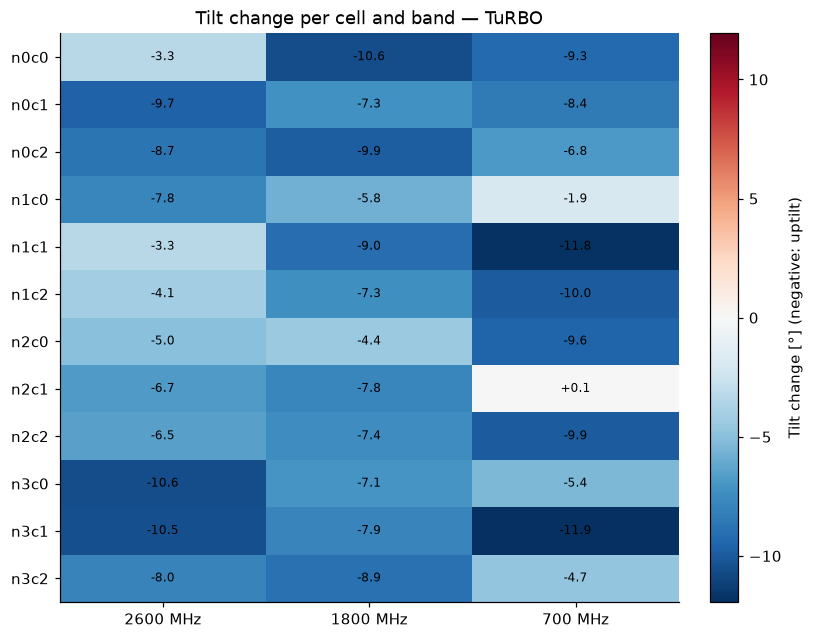

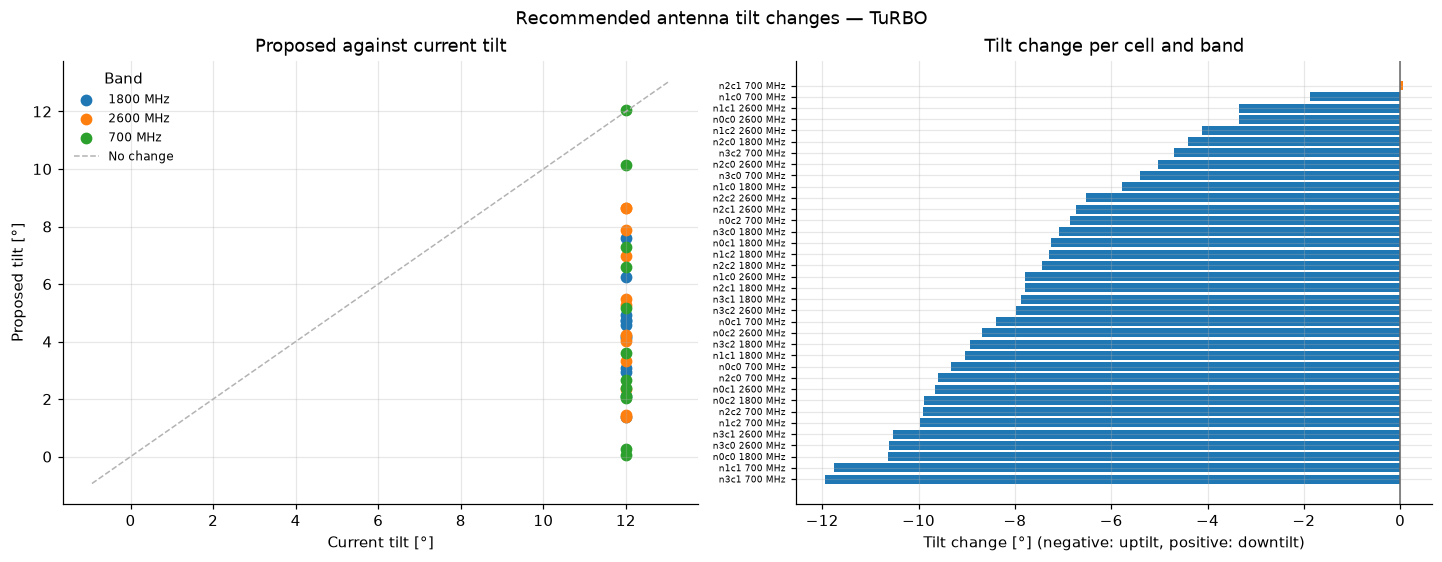

,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n3,n3c1,165.0,2600 MHz,12.0,1.4641,-10.5359,178,0.9974,-1.0901,365,0.9832,0.7562,187,-0.0143,1.8463
1,n2,n2c1,165.0,2600 MHz,12.0,5.2635,-6.7365,588,0.9990,2.7637,764,0.9992,6.3656,176,0.0002,3.6018
2,n0,n0c2,285.0,2600 MHz,12.0,3.3161,-8.6839,79,0.9897,1.7382,237,0.9979,1.6295,158,0.0082,-0.1087
3,n1,n1c1,165.0,1800 MHz,12.0,2.9545,-9.0455,46,0.9511,1.7939,141,0.9656,2.8968,95,0.0145,1.1029
4,n0,n0c1,165.0,2600 MHz,12.0,2.3407,-9.6593,242,0.9923,6.7901,334,0.9763,8.4835,92,-0.0160,1.6934
5,n1,n1c0,45.0,2600 MHz,12.0,4.2175,-7.7825,420,0.9945,1.3985,488,0.9992,2.9963,68,0.0048,1.5978
6,n3,n3c2,285.0,2600 MHz,12.0,4.0142,-7.9858,534,0.9880,4.7005,592,0.9907,5.7516,58,0.0027,1.0511
7,n1,n1c1,165.0,2600 MHz,12.0,8.6551,-3.3449,128,0.9870,0.9380,181,0.9929,3.9100,53,0.0058,2.9719
8,n1,n1c0,45.0,1800 MHz,12.0,6.2308,-5.7692,104,0.9958,2.7472,54,0.9930,5.3276,-50,-0.0028,2.5805
9,n2,n2c2,285.0,2600 MHz,12.0,5.4810,-6.5190,190,0.9901,4.0934,234,0.9928,8.6659,44,0.0026,4.5725


In [16]:
display(results["recommended_tilt"])
display(results["tilt_movement_summary"])
display(results["tilt_delta_heatmap"])
display(results["tilt_movement"])
display(results["cell_impact"])

**Observations.** TuRBO uptilts 35 of 36 cell-bands, by 7–8° on average per band; only n2c1 on 700 MHz stays at its current tilt. Several proposed tilts sit near the 0° lower bound, which suggests the uniform 12° current tilt is too much downtilt for this scenario and the bound may be limiting the search. The largest traffic shifts are on 2600 MHz sectors facing 165° and 285° (top of the cell impact table), so those cells need watching after rollout.

## 14. Computational Cost

The expensive part is ray tracing, which is summed over every evaluation, apart from algorithm overhead (the difference
to wall clock: GP fitting and acquisition for TuRBO, I/O for all).

In [17]:
cost = results["method_cost"][["Method", "Seed", "Evaluations", "Ray tracing [min]", "Wall clock [min]"]].copy()
cost["Ray tracing per evaluation [s]"] = cost["Ray tracing [min]"] * 60 / cost["Evaluations"]
cost["Overhead [min]"] = cost["Wall clock [min]"] - cost["Ray tracing [min]"]
display(cost)

,Method,Seed,Evaluations,Ray tracing [min],Wall clock [min],Ray tracing per evaluation [s],Overhead [min]
0,Random search,42,145,12.1439,15.3656,5.0251,3.2218
1,Rule-based sweep,42,28,1.1977,2.2115,2.5666,1.0137
2,TuRBO,42,145,9.8646,19.4349,4.0819,9.5702


**Observations.** Ray tracing takes a few seconds per evaluation. On the same budget, TuRBO spent less total ray-tracing time than random search; this run doesn't show why. TuRBO's GP fitting and acquisition overhead nearly doubles its wall clock. The rule sweep delivers an equivalent result in about a tenth of TuRBO's wall clock.

## 15. Sensitivity Analysis

Only the objective weight $\gamma$ (`kpi.objective.gamma`) can vary without re-tracing: the history stores
$J_{\text{radio}}$ and $J_{\text{load}}$, and every other objective parameter is inside them. The table re-picks each
run's winner from its own evaluated configurations under each $\gamma$ (MDT-scored).

Not implemented, because each needs new ray-tracing runs: initial design size, budget, trust-region settings, the
thresholds $T_{\text{hole}}$ / $\Delta_{\text{overlap}}$, $\tau_R$, $\beta$, $\rho_0$, $\alpha$, the UE density model and
tilt bounds.

In [18]:
display(results["gamma_sensitivity"])

,Method,Seed,gamma,Best evaluation,Same pick as the run,Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Radio utility J_radio,Load utility J_load,Objective J
0,Random search,42,0.00,21,False,0.1728,0.3186,0.9860,0.2952,-110.4340,0.5488,0.9585,0.9585
1,Rule-based sweep,42,0.00,23,False,0.1743,0.3329,0.9887,0.2640,-109.9046,0.5362,0.9613,0.9613
2,TuRBO,42,0.00,122,False,0.1658,0.2743,0.9911,0.2627,-109.3827,0.5857,0.9655,0.9655
3,Random search,42,0.25,95,False,0.1695,0.2872,0.9691,0.2693,-109.5945,0.5741,0.9501,0.8377
4,Rule-based sweep,42,0.25,16,False,0.1632,0.2775,0.9906,0.2583,-109.3156,0.5823,0.9600,0.8472
5,TuRBO,42,0.25,122,False,0.1658,0.2743,0.9911,0.2627,-109.3827,0.5857,0.9655,0.8521
6,Random search,42,0.50,7,True,0.1680,0.2810,0.9795,0.2847,-109.9979,0.5777,0.9461,0.7393
7,Rule-based sweep,42,0.50,20,True,0.1639,0.2744,0.9920,0.2594,-109.3382,0.5843,0.9575,0.7480
8,TuRBO,42,0.50,144,True,0.1659,0.2730,0.9918,0.2632,-109.3873,0.5864,0.9647,0.7521
9,Random search,42,0.75,7,True,0.1680,0.2810,0.9795,0.2847,-109.9979,0.5777,0.9461,0.6535


**Observations.** Each method keeps its pick for gamma between 0.5 (the configured value) and 0.75. Weighting load more (gamma ≤ 0.25) changes every method's pick towards configurations with higher J_load. Weighting radio only (gamma = 1) changes TuRBO's pick to one with slightly lower overlap and a slightly higher hole rate. The recommendation therefore holds near the configured gamma, but it is not invariant to it.

## 16. Key Results

The recommended TuRBO winner against the current configuration and the best baseline (highest objective score among
random search and the rule-based sweep), every UE. The improvement column is TuRBO relative to the current
configuration, positive is better.

In [19]:
board = results["kpi_scoreboard"]
means = board.pivot(index="KPI", columns="Method", values="Mean")
current = board.drop_duplicates("KPI").set_index("KPI")["Current configuration"]
baselines = [m for m in means.columns if m != "TuRBO"]
best_baseline = means.loc["Objective J", baselines].idxmax()
improvement = results["kpi_relative_improvement"].set_index("Method").loc["TuRBO"]
order = list(dict.fromkeys(board["KPI"]))
key_results = pd.DataFrame(
    {
        "Current configuration": current,
        f"Best baseline ({best_baseline})": means[best_baseline],
        "TuRBO": means["TuRBO"],
        "TuRBO improvement [%]": improvement,
    }
).loc[order]
display(key_results)

,Current configuration,Best baseline (Rule-based sweep),TuRBO,TuRBO improvement [%]
Coverage hole rate,0.1840,0.1639,0.1659,9.8344
Co-band overlap rate,0.2689,0.2744,0.2730,-1.5420
Served UE ratio,0.4121,0.5163,0.5133,24.5661
Weak coverage rate,0.4063,0.2594,0.2632,35.2329
Cell-edge RSRP,-112.2728,-109.3382,-109.3873,2.5701
Radio utility J_radio,0.5568,0.5843,0.5864,5.3153
Load utility J_load,0.8349,0.8681,0.8656,3.6734
Objective J,0.6818,0.7122,0.7124,4.4911


### Main observations

* **Coverage:** TuRBO cuts the hole rate by about 10 % and the weak-coverage rate by about 35 % relative to the current configuration, and lifts cell-edge RSRP by about 2.9 dB.
* **Overlap:** the co-band overlap rate rises slightly (+1.5 % relative) and mean overlap neighbours rise, but pile-ups of three or more neighbours fall. This is the one KPI no method improved.
* **Band coordination:** the added served UEs land on 2600 MHz (28 % to 38 % of reports), and SINR improves on all bands.
* **Optimization efficiency:** TuRBO matches the rule-based sweep after about 50 evaluations and edges past it by 145. Random search stalls within 10.
* **Robustness:** unknown, since only one seed per method exists. TuRBO's margin over the best baseline (rule-based sweep) is too small to call a win.

## 17. Figures for Presentation

All saved under `reports/figures/04_evaluation/`.

| # | Figure | File | Purpose |
|---|---|---|---|
| 1 | Overall KPI comparison | `kpi_improvement.png` | Direct comparison of every method's improvement |
| 2 | Optimization convergence | `search_progress.png` | Sample efficiency of the search |
| 3 | Hole–overlap trade-off | `tradeoff_hole_rate_vs_overlap_rate.png` | Coverage against overlap, with the Pareto front |
| 4 | Coverage before vs after | `coverage_before_after.png`, `coverage_class_maps.png` | Where coverage changed |
| 5 | Serving band distribution | `serving_band_mix.png` | Whether multi-band coordination behaves as intended |
| 6 | Tilt adjustment heatmap | `tilt_delta_heatmap.png` | What the optimizer decided |

## 18. Conclusions

1. **Holes:** yes. Every method reduces them by 9–11 % relative, nearly all on tiles without demand.
2. **Co-band overlap:** no. It rises slightly under every method; TuRBO worsens it least.
3. **Overlapping neighbours:** the mean per covered tile rises, but the share of tiles with three or more neighbours falls.
4. **Frequency layers:** the extra coverage is served mainly on the preferred 2600 MHz layer, not shifted off the lower bands.
5. **Consistency across runs:** not measurable yet, with one seed per method.
6. **Evaluations needed:** the rule sweep reaches its result in 28 evaluations; TuRBO needs about 50 to match it.
7. **Tilt changes:** a broad uptilt of about 7–8° on almost every cell-band, several close to the 0° bound.
8. **Remaining trade-off:** coverage against overlap. Uptilting closes holes and weak areas and pushes more neighbours into each other's footprint.

**Final summary.** TuRBO achieved a 4.5 % higher objective than the current configuration, with 10 % fewer holes, 35 % less weak coverage and 25 % more served UEs, at the cost of 1.5 % more co-band overlap. The rule-based sweep reached practically the same result (J 0.7122 against 0.7124) in 28 evaluations. TuRBO needed about 50 evaluations to match it, while random search stalled early. On this scenario and single seed, a coordinated uptilt explains most of the gain, and the search method matters less than the budget. Multi-seed runs, and a tilt lower bound below 0° if hardware allows, are needed before recommending TuRBO over the sweep.

### Threats to validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | — | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | — | Open: re-tracing under other solver seeds is not implemented |
| 3 | Weak reference: the current configuration uses one identical tilt for every cell-band | Section 7, winner against candidates | Reported |
| 4 | One search seed per method: no spread, interval or test | Section 9 | Open |
| 5 | The objective depends on judgement parameters (tau_R, beta, rho_0, alpha, gamma) | Section 15, gamma only | Partly mitigated: only gamma is varied |
| 6 | Hole and weak rates count area, including area without users | Section 11.2, coverage by area and by demand | Reported |
| 7 | The served ratio relies on placeholder capacity settings | `configs/kpi.yaml` `capacity` | Open |
| 8 | Search traces (convergence, sample efficiency, trade-offs, gamma) are MDT-scored; the scoreboard is every UE | Sections 6–10 | Reported |
| 9 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements | Notebook 01, data quality | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement is not constrained | Sections 8, 13, 14 | Reported |
| 11 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | — | Open |

## Appendix — Reproducibility

In [20]:
import platform
from importlib.metadata import version

from omegaconf import OmegaConf

setup = results["experiment_setup"].set_index("Parameter")["Setting"]
commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
record = {
    "Scenario": setup["Scenario"],
    "Code commit": f"{commit}{' (uncommitted changes)' if dirty else ''}",
    "Runs": ", ".join(f"{m}/{r}" for m, r in results["method_cost"][["Method", "Run"]].itertuples(index=False)),
    "Search seeds": sorted(results["method_cost"]["Seed"].unique().tolist()),
    "Global seed": cfg.seed,
    "Tilt bounds [°]": setup["Tilt bounds [°]"],
    "Tilt step / maximum change": "none (continuous, unconstrained change)",
    "KPI thresholds": OmegaConf.to_container(cfg.kpi, resolve=True),
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    **{name: version(name) for name in ("numpy", "pandas", "scipy", "matplotlib", "hydra-core")},
}
for key, value in record.items():
    print(f"{key}: {value}")

Scenario: scn_7d938e15f9ac4618
Code commit: afe25fcc7e25f983e1575b68be5598aa911a9b0a (uncommitted changes)
Runs: Random search/2026-09-17_07-25-42, Rule-based sweep/2026-09-17_07-41-04, TuRBO/2026-09-17_07-57-05
Search seeds: [42]
Global seed: 42
Tilt bounds [°]: 0 to 15
Tilt step / maximum change: none (continuous, unconstrained change)
KPI thresholds: {'hole_dbm': -120.0, 'weak_dbm': -90.0, 'overlap_margin_db': 6.0, 'objective': {'tau_r_db': 10.0, 'beta': 1.0, 'rho_0': 0.8, 'alpha': 0.9, 'gamma': 0.5}, 'quality': {'edge_percentile': 5.0}, 'capacity': {'band_preference': ['b2600', 'b1800', 'b700'], 'rsrp_threshold_dbm': -120.0, 'max_admission_utilisation': 0.8, 'throughput_per_ue_bps': 20000000, 'bands': {'b2600': {'scs_hz': 15000}, 'b1800': {'scs_hz': 15000}, 'b700': {'scs_hz': 15000}}}}
Python: 3.13.14
Platform: Windows-11-10.0.26200-SP0
numpy: 2.5.2
pandas: 2.3.3
scipy: 1.18.1
matplotlib: 3.11.1
hydra-core: 1.3.6
